# Thesis Experiment Analysis

This notebook contains only the analyses and figures used in the thesis results chapter. It excludes earlier exploratory debugging cells, database-fix cells, and unused broad checks.

It reproduces: the final participant sample, pre/post ranking performance, learning-effect tests, personal-product follow-up analyses, prior-belief checks, and the catalog-level CO$_2$ distribution figure.

In [11]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    from dotenv import load_dotenv
    from supabase import create_client
except ImportError:
    load_dotenv = None
    create_client = None

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)


def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'analysis' / 'experiment_analysis.ipynb').exists():
            return candidate
        if candidate.name == 'analysis' and (candidate / 'experiment_analysis.ipynb').exists():
            return candidate.parent
    raise RuntimeError('Could not locate sustainable-shop-webapp project root')


PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / 'analysis'
OUTPUT_DIR = ANALYSIS_DIR / 'analysis_output'
THESIS_IMAGE_DIR = ANALYSIS_DIR / 'thesis' / 'images'
OUTPUT_DIR.mkdir(exist_ok=True)
THESIS_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

USE_CACHED_EXPORT = True
CACHED_EXPORT = OUTPUT_DIR / 'experiment_data_full.json'
CATALOG_EXPORT = OUTPUT_DIR / 'ah_catalog_co2_evaluated.json'

print(f'Project root: {PROJECT_ROOT}')
print(f'Analysis output: {OUTPUT_DIR}')
print(f'Thesis images: {THESIS_IMAGE_DIR}')

Project root: /home/montague/Downloads/AH2/sustainable-shop-webapp
Analysis output: /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/analysis_output
Thesis images: /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/thesis/images


## 1. Load and flatten experiment sessions

The thesis uses completed experiment sessions. By default this notebook reads the cached export in `analysis_output/experiment_data_full.json`, so the results can be checked without requiring live Supabase credentials. If the cached export is unavailable, it falls back to Supabase using the project `.env` file.

In [12]:
def fetch_data_from_supabase(completed_only=True):
    if load_dotenv is None or create_client is None:
        raise ImportError('python-dotenv and supabase are required for live Supabase loading')

    load_dotenv(PROJECT_ROOT / '.env')
    supabase_url = os.getenv('SUPABASE_URL')
    supabase_key = os.getenv('SUPABASE_SERVICE_ROLE_KEY') or os.getenv('SUPABASE_ANON_KEY')

    if not supabase_url or not supabase_key:
        raise ValueError('Missing SUPABASE_URL and SUPABASE_SERVICE_ROLE_KEY/SUPABASE_ANON_KEY in .env')

    sb = create_client(supabase_url, supabase_key)
    query = sb.table('experiment_sessions').select('*').order('started_at', desc=False)
    if completed_only:
        query = query.eq('current_step', 'complete')
    resp = query.execute()
    sessions = resp.data or []
    return {
        'exportedAt': datetime.now(timezone.utc).isoformat(),
        'count': len(sessions),
        'completedCount': sum(1 for s in sessions if s.get('current_step') == 'complete'),
        'sessions': sessions,
        'source': 'supabase_direct',
    }


def load_experiment_data():
    if USE_CACHED_EXPORT and CACHED_EXPORT.exists():
        with open(CACHED_EXPORT, 'r', encoding='utf-8') as f:
            data = json.load(f)
        data['source'] = data.get('source', 'cached_export')
        return data

    data = fetch_data_from_supabase(completed_only=True)
    with open(CACHED_EXPORT, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, default=str)
    return data


def quiz_score(session, quiz_key):
    return (session.get(quiz_key) or {}).get('score')


def flatten_session(session):
    demographics = session.get('demographics') or {}
    pre_q = session.get('pre_questionnaire') or {}
    post_q = session.get('post_questionnaire_closed') or {}
    row = {
        'id': session.get('id'),
        'current_step': session.get('current_step'),
        'cart_source': (session.get('cart_source') or '').strip().lower(),
        'started_at': session.get('started_at'),
        'completed_at': session.get('completed_at'),
        'demo_age': demographics.get('demo_age'),
        'demo_gender': demographics.get('demo_gender'),
        'demo_education': demographics.get('demo_education'),
        'demo_diet': demographics.get('demo_diet'),
        'demo_shopping_frequency': demographics.get('demo_shopping_frequency'),
        'generic_pre': quiz_score(session, 'quiz1_data'),
        'generic_post': quiz_score(session, 'quiz3_data'),
        'ah_pre': quiz_score(session, 'quiz5_data'),
        'ah_post': quiz_score(session, 'quiz6_data'),
        'personal_pre': quiz_score(session, 'quiz2_data'),
        'personal_post': quiz_score(session, 'quiz4_data'),
        'pre_q7': pre_q.get('organic_co2_belief'),
        'pre_q8': pre_q.get('organic_label_indicator'),
    }
    for key, value in pre_q.items():
        if key.startswith('pre_q'):
            row[key] = value
    for key, value in post_q.items():
        if key.startswith('post_q'):
            row[key] = value
    return row


raw_data = load_experiment_data()
sessions = raw_data.get('sessions', [])
df_all = pd.DataFrame([flatten_session(s) for s in sessions])

for col in ['started_at', 'completed_at']:
    if col in df_all.columns:
        df_all[col] = pd.to_datetime(df_all[col], errors='coerce')

for prefix in ['generic', 'ah', 'personal']:
    df_all[f'{prefix}_improvement'] = df_all[f'{prefix}_post'] - df_all[f'{prefix}_pre']

df_all['overall_baseline'] = df_all[['generic_pre', 'ah_pre', 'personal_pre']].mean(axis=1)
df_all['overall_improvement'] = df_all[['generic_improvement', 'ah_improvement', 'personal_improvement']].mean(axis=1)

print(f"Loaded {len(df_all)} sessions from {raw_data.get('source', 'unknown')}")
print(df_all[['current_step', 'cart_source']].value_counts(dropna=False).sort_index())
df_all.head()

Loaded 105 sessions from supabase_direct
current_step  cart_source  
complete      predefined        4
              scraped          20
              self_selected    81
Name: count, dtype: int64


,id,current_step,cart_source,started_at,completed_at,demo_age,demo_gender,demo_education,demo_diet,demo_shopping_frequency,generic_pre,generic_post,ah_pre,ah_post,personal_pre,personal_post,pre_q7,pre_q8,pre_q1,pre_q2,pre_q3,pre_q4,pre_q5,pre_q6,post_q1,post_q2,post_q3,post_q4,post_q5,post_q6,post_q7,generic_improvement,ah_improvement,personal_improvement,overall_baseline,overall_improvement
0,bbb08a68-8e6c-4c77-9d1e-cfc919c79a24,complete,scraped,2026-04-16 15:45:45.005665+00:00,2026-04-16 15:59:45.222000+00:00,21,man,None,omnivore,2_3_per_week,67,56,22,56,67,56,5,3,2,4,3,5,4,3,4,4,5,5,5,4,5,-11,34,-11,52.000000,4.000000
1,eec44ee2-1b77-4092-9389-edda175a59d8,complete,scraped,2026-04-16 16:03:32.866218+00:00,2026-04-16 16:15:57.416000+00:00,23,woman,None,vegetarian,weekly,78,56,56,78,67,56,1,1,4,4,3,5,4,4,5,5,4,5,5,5,5,-22,22,-11,67.000000,-3.666667
2,e2299ec3-fd9b-4ffc-b5ab-37d1f7132358,complete,scraped,2026-04-16 16:04:09.867803+00:00,2026-04-16 16:23:00.663000+00:00,21,woman,None,omnivore,weekly,89,56,44,78,56,44,2,1,3,4,4,2,1,3,4,5,4,5,5,5,5,-33,34,-12,63.000000,-3.666667
3,d47f010d-05e3-436e-98d7-1f4b91b239c6,complete,scraped,2026-04-17 11:20:02.663981+00:00,2026-04-17 11:36:40.244000+00:00,23,man,None,omnivore,2_3_per_week,67,89,67,67,67,100,4,5,3,2,4,4,2,2,4,5,5,4,4,3,4,22,0,33,67.000000,18.333333
4,3b4aacff-b057-4e0f-b499-d7ca5f178ed4,complete,scraped,2026-04-17 11:25:22.123299+00:00,2026-04-17 11:49:59.328000+00:00,27,prefer_not_to_say,None,vegetarian,2_3_per_week,56,44,44,67,33,11,2,1,3,4,1,1,2,4,4,5,3,4,5,4,3,-12,23,-22,44.333333,-3.666667


## 2. Final analysis sample

The final thesis analysis uses completed sessions and excludes four completed predefined-cart sessions from an earlier fallback route.

In [13]:
completed_df = df_all[df_all['current_step'].eq('complete')].copy()
predefined_df = completed_df[completed_df['cart_source'].eq('predefined')].copy()
analysis_df = completed_df[~completed_df['cart_source'].eq('predefined')].copy()

score_cols = ['generic_pre', 'generic_post', 'ah_pre', 'ah_post', 'personal_pre', 'personal_post']
analysis_df = analysis_df.dropna(subset=score_cols).copy()

print(f'Completed sessions before exclusion: {len(completed_df)}')
print(f'Excluded predefined-cart sessions: {len(predefined_df)}')
print(f'Final analysis sample: n={len(analysis_df)}')
print('Cart sources in final sample:')
print(analysis_df['cart_source'].value_counts(dropna=False))

Completed sessions before exclusion: 105
Excluded predefined-cart sessions: 4
Final analysis sample: n=101
Cart sources in final sample:
cart_source
self_selected    81
scraped          20
Name: count, dtype: int64


## 3. Pre/post ranking performance and significance tests

This section produces the descriptive statistics and paired t-tests reported in Chapter 4.

In [14]:
QUIZ_CONTEXTS = [
    ('generic', 'Generic products'),
    ('ah', 'Albert Heijn-specific products'),
    ('personal', 'Personal products'),
]


def paired_learning_stats(data, prefix, label):
    pre_col = f'{prefix}_pre'
    post_col = f'{prefix}_post'
    paired = data[[pre_col, post_col]].dropna()
    pre = paired[pre_col]
    post = paired[post_col]
    diff = post - pre
    t_stat, p_value = stats.ttest_rel(post, pre)
    return {
        'context': label,
        'n': len(paired),
        'pre_mean': pre.mean(),
        'pre_sd': pre.std(),
        'post_mean': post.mean(),
        'post_sd': post.std(),
        'improvement': diff.mean(),
        'percent_change': 100 * diff.mean() / pre.mean(),
        't': t_stat,
        'p': p_value,
        'cohens_dz': diff.mean() / diff.std(),
    }


learning_results = pd.DataFrame([
    paired_learning_stats(analysis_df, prefix, label)
    for prefix, label in QUIZ_CONTEXTS
])

display(learning_results.round({
    'pre_mean': 2, 'pre_sd': 2, 'post_mean': 2, 'post_sd': 2,
    'improvement': 2, 'percent_change': 1, 't': 3, 'p': 12, 'cohens_dz': 3
}))

,context,n,pre_mean,pre_sd,post_mean,post_sd,improvement,percent_change,t,p,cohens_dz
0,Generic products,101,45.88,30.56,64.31,21.88,18.43,40.2,5.950,3.971200e-08,0.592
1,Albert Heijn-specific products,101,44.73,23.39,63.70,22.47,18.97,42.4,7.026,2.630000e-10,0.699
2,Personal products,101,54.58,22.81,58.83,25.15,4.25,7.8,1.539,1.270389e-01,0.153


## 4. Thesis figure for pre/post scores and learning effects

This cell regenerates the combined Figure 4.2 in the thesis image folder. The upper panels show pre/post score distributions, while the lower panel summarizes the mean learning effect with 95% confidence intervals.

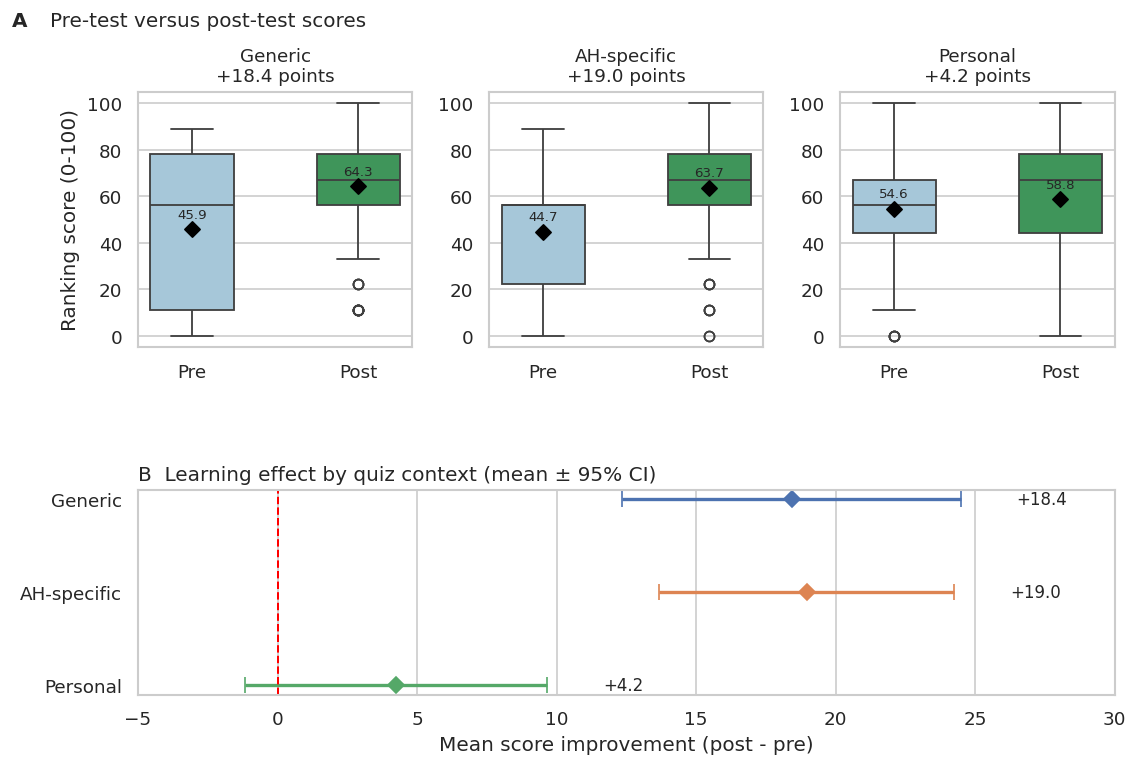

Saved /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/thesis/images/pre_post_scores_by_context.png


In [19]:
# Shared thesis figure style
THESIS_PALETTE = {
    'pre': '#9ecae1',
    'post': '#31a354',
    'generic': '#4C72B0',
    'ah': '#DD8452',
    'personal': '#55A868',
    'mean': '#7f0000',
}
SHORT_LABELS = {
    'Generic products': 'Generic',
    'Albert Heijn-specific products': 'AH-specific',
    'Personal products': 'Personal',
}

# Figure 4.2: pre/post score distributions plus learning-effect summary.
fig = plt.figure(figsize=(10.5, 6.7))
grid = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], hspace=0.62, wspace=0.28, top=0.86)
score_axes = [fig.add_subplot(grid[0, i]) for i in range(3)]
effect_ax = fig.add_subplot(grid[1, :])

for ax, (prefix, label) in zip(score_axes, QUIZ_CONTEXTS):
    pre_col = f'{prefix}_pre'
    post_col = f'{prefix}_post'
    plot_df = pd.DataFrame({
        'Score': pd.concat([analysis_df[pre_col], analysis_df[post_col]], ignore_index=True),
        'Phase': ['Pre'] * len(analysis_df) + ['Post'] * len(analysis_df),
    })

    sns.boxplot(
        data=plot_df,
        x='Phase',
        y='Score',
        hue='Phase',
        palette=[THESIS_PALETTE['pre'], THESIS_PALETTE['post']],
        width=0.5,
        showfliers=True,
        linewidth=1.1,
        ax=ax,
        legend=False,
    )

    means = [analysis_df[pre_col].mean(), analysis_df[post_col].mean()]
    ax.scatter([0, 1], means, marker='D', s=42, color='black', zorder=4)
    for x_pos, mean in enumerate(means):
        ax.text(x_pos, mean + 3.5, f'{mean:.1f}', ha='center', va='bottom', fontsize=8)

    improvement = means[1] - means[0]
    ax.set_title(f"{SHORT_LABELS[label]}\n{improvement:+.1f} points", fontsize=11)
    ax.set_xlabel('')
    ax.set_ylim(-5, 105)
    ax.grid(axis='x', visible=False)

score_axes[0].set_ylabel('Ranking score (0-100)')
for ax in score_axes[1:]:
    ax.set_ylabel('')
fig.text(0.025, 0.96, 'A', fontsize=12, fontweight='bold', va='top')
fig.text(0.055, 0.96, 'Pre-test versus post-test scores', fontsize=12, va='top')

summary_rows = []
for prefix, label in QUIZ_CONTEXTS:
    values = analysis_df[f'{prefix}_improvement'].dropna()
    mean = values.mean()
    sem = values.std(ddof=1) / np.sqrt(len(values))
    ci95 = 1.96 * sem
    summary_rows.append({
        'Context': SHORT_LABELS[label],
        'Mean improvement': mean,
        'CI95': ci95,
        'n': len(values),
        'color': THESIS_PALETTE[prefix],
    })
improvement_summary = pd.DataFrame(summary_rows)

y_positions = np.arange(len(improvement_summary))[::-1]
for y_pos, (_, row) in zip(y_positions, improvement_summary.iterrows()):
    effect_ax.errorbar(
        row['Mean improvement'],
        y_pos,
        xerr=row['CI95'],
        fmt='D',
        markersize=7,
        color=row['color'],
        ecolor=row['color'],
        elinewidth=2,
        capsize=5,
    )
    effect_ax.text(
        row['Mean improvement'] + row['CI95'] + 2,
        y_pos,
        f"{row['Mean improvement']:+.1f}",
        va='center',
        fontsize=10,
    )

effect_ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
effect_ax.set_yticks(y_positions)
effect_ax.set_yticklabels(improvement_summary['Context'])
effect_ax.set_xlabel('Mean score improvement (post - pre)')
effect_ax.set_title('B  Learning effect by quiz context (mean ± 95% CI)', loc='left', fontsize=12)
effect_ax.set_xlim(-5, 30)
effect_ax.grid(axis='y', visible=False)

combined_learning_path = THESIS_IMAGE_DIR / 'pre_post_scores_by_context.png'
plt.savefig(combined_learning_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {combined_learning_path}')

## 5. Personal-product gains

This section checks whether personal-product quizzes had a narrower CO$_2$ range and whether results differed by cart source. These values support the discussion of why the personal-product learning effect was smaller.

,context,mean_range,median_range,share_below_10
0,Generic products,37.87,37.87,0.000
1,Albert Heijn-specific products,17.90,17.90,0.000
2,Personal products,12.73,7.31,0.584


,context,mean_spread,median_spread,q1,q3,share_spread_below_10,iqr
0,Generic,37.87,37.87,37.87,37.87,0.000,0.0
1,AH-specific,17.90,17.90,17.90,17.90,0.000,0.0
2,Personal,12.73,7.31,6.22,16.42,0.584,10.2


Interpretation: personal carts show the smallest CO2 spread (median=7.31) versus AH-specific (median=17.90) and generic (median=37.87).
Personal CO2 range vs personal improvement: r=0.064, p=0.526, n=101


personal_pre               personal_post                \
                     count   mean    std         count   mean    std   
cart_source                                                            
scraped                 20  58.00  21.05            20  59.60  24.89   
self_selected           81  53.74  23.27            81  58.64  25.36   

              personal_improvement              
                             count mean    std  
cart_source                                     
scraped                         20  1.6  22.48  
self_selected                   81  4.9  28.98

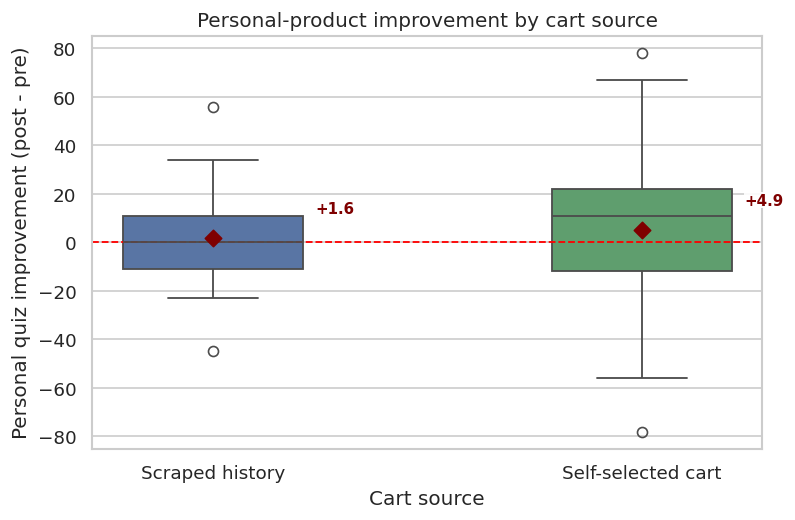

Saved /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/thesis/images/personal_improvement_by_cart_source.png
Saved /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/thesis/presentation_images/personal_improvement_by_cart_source.png


In [24]:
SESSION_BY_ID = {s.get('id'): s for s in sessions}
CO2_KEYS = ['co2PerKg', 'co2_per_kg', 'co2', 'emissions']


def quiz_items(session, quiz_key):
    quiz = session.get(quiz_key) or {}
    for field in ['items', 'correctOrder', 'user_ranking']:
        items = quiz.get(field)
        if isinstance(items, list) and items:
            return items
    return []


def item_co2_value(item):
    for key in CO2_KEYS:
        value = item.get(key)
        if value is not None:
            try:
                value = float(value)
                if np.isfinite(value):
                    return value
            except (TypeError, ValueError):
                pass
    return np.nan


def quiz_co2_range(session, quiz_key):
    values = [item_co2_value(item) for item in quiz_items(session, quiz_key)]
    values = [v for v in values if np.isfinite(v)]
    if len(values) < 2:
        return np.nan
    return max(values) - min(values)


range_rows = []
for _, row in analysis_df.iterrows():
    session = SESSION_BY_ID.get(row['id'], {})
    range_rows.append({
        'id': row['id'],
        'cart_source': row['cart_source'],
        'generic_range': quiz_co2_range(session, 'quiz1_data'),
        'ah_range': quiz_co2_range(session, 'quiz5_data'),
        'personal_range': quiz_co2_range(session, 'quiz2_data'),
        'personal_improvement': row['personal_improvement'],
    })
range_df = pd.DataFrame(range_rows)

range_summary = pd.DataFrame({
    'context': ['Generic products', 'Albert Heijn-specific products', 'Personal products'],
    'mean_range': [range_df['generic_range'].mean(), range_df['ah_range'].mean(), range_df['personal_range'].mean()],
    'median_range': [range_df['generic_range'].median(), range_df['ah_range'].median(), range_df['personal_range'].median()],
    'share_below_10': [
        (range_df['generic_range'] < 10).mean(),
        (range_df['ah_range'] < 10).mean(),
        (range_df['personal_range'] < 10).mean(),
    ],
})
display(range_summary.round({'mean_range': 2, 'median_range': 2, 'share_below_10': 3}))

spread_table = pd.DataFrame({
    'context': ['Generic', 'AH-specific', 'Personal'],
    'mean_spread': [range_df['generic_range'].mean(), range_df['ah_range'].mean(), range_df['personal_range'].mean()],
    'median_spread': [range_df['generic_range'].median(), range_df['ah_range'].median(), range_df['personal_range'].median()],
    'q1': [range_df['generic_range'].quantile(0.25), range_df['ah_range'].quantile(0.25), range_df['personal_range'].quantile(0.25)],
    'q3': [range_df['generic_range'].quantile(0.75), range_df['ah_range'].quantile(0.75), range_df['personal_range'].quantile(0.75)],
    'share_spread_below_10': [
        (range_df['generic_range'] < 10).mean(),
        (range_df['ah_range'] < 10).mean(),
        (range_df['personal_range'] < 10).mean(),
    ],
})
spread_table['iqr'] = spread_table['q3'] - spread_table['q1']
display(spread_table.round({'mean_spread': 2, 'median_spread': 2, 'q1': 2, 'q3': 2, 'iqr': 2, 'share_spread_below_10': 3}))

personal_median = spread_table.loc[spread_table['context'].eq('Personal'), 'median_spread'].iloc[0]
generic_median = spread_table.loc[spread_table['context'].eq('Generic'), 'median_spread'].iloc[0]
ah_median = spread_table.loc[spread_table['context'].eq('AH-specific'), 'median_spread'].iloc[0]
print(f'Interpretation: personal carts show the smallest CO2 spread (median={personal_median:.2f}) versus AH-specific (median={ah_median:.2f}) and generic (median={generic_median:.2f}).')

range_corr = range_df[['personal_range', 'personal_improvement']].dropna()
r, p = stats.pearsonr(range_corr['personal_range'], range_corr['personal_improvement'])
print(f"Personal CO2 range vs personal improvement: r={r:.3f}, p={p:.3f}, n={len(range_corr)}")

cart_source_summary = (
    analysis_df
    .groupby('cart_source')[['personal_pre', 'personal_post', 'personal_improvement']]
    .agg(['count', 'mean', 'std'])
)
display(cart_source_summary.round(2))

valid_cart_sources = analysis_df[analysis_df['cart_source'].isin(['scraped', 'self_selected'])].copy()
source_order = ['scraped', 'self_selected']
source_labels = ['Scraped history', 'Self-selected cart']
source_palette = ['#4C72B0', '#55A868']

fig, ax = plt.subplots(figsize=(6.8, 4.5))
sns.boxplot(
    data=valid_cart_sources,
    x='cart_source',
    y='personal_improvement',
    order=source_order,
    hue='cart_source',
    palette=source_palette,
    width=0.42,
    showfliers=True,
    linewidth=1.1,
    ax=ax,
    legend=False,
)

means = valid_cart_sources.groupby('cart_source')['personal_improvement'].mean().reindex(source_order)
y_min = valid_cart_sources['personal_improvement'].min()
y_max = valid_cart_sources['personal_improvement'].max()
y_span = max(1.0, y_max - y_min)

for x_pos, (source, mean_value) in enumerate(means.items()):
    ax.scatter(x_pos, mean_value, marker='D', s=48, color='#7f0000', zorder=6)

    x_offset = 0.24
    ha = 'left'
    y_offset = max(3.5, 0.06 * y_span)

    ax.text(
        x_pos + x_offset,
        mean_value + y_offset,
        f'{mean_value:+.1f}',
        ha=ha,
        va='bottom',
        fontsize=9,
        color='#7f0000',
        fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=0.25),
        zorder=7,
    )

ax.axhline(0, color='red', linestyle='--', linewidth=1.1)
ax.set_xlabel('Cart source')
ax.set_ylabel('Personal quiz improvement (post - pre)')
ax.set_title('Personal-product improvement by cart source')
ax.set_xticks([0, 1], source_labels)
ax.set_ylim(-85, 85)
plt.tight_layout()

cart_source_path = THESIS_IMAGE_DIR / 'personal_improvement_by_cart_source.png'
plt.savefig(cart_source_path, dpi=300, bbox_inches='tight')

presentation_path = THESIS_IMAGE_DIR.parent / 'presentation_images' / 'personal_improvement_by_cart_source.png'
presentation_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(presentation_path, dpi=300, bbox_inches='tight')

plt.show()
print(f'Saved {cart_source_path}')
print(f'Saved {presentation_path}')

## 6. Exploratory checks: prior beliefs and performance

This section visualizes exploratory correlations between pre-questionnaire beliefs/self-assessments and two outcomes: baseline ranking accuracy and learning improvement.

A near-zero pattern across items supports the interpretation that prior beliefs were not strongly related to initial performance or gains in this sample.

,belief,outcome,r,p,n,ci_low,ci_high
0,Perceived diet sustainability,Baseline score,0.146,0.147,101,-0.051,0.332
1,Perceived diet sustainability,Learning improvement,-0.095,0.346,101,-0.285,0.103
2,Confidence in impact knowledge,Baseline score,0.041,0.684,101,-0.156,0.235
3,Confidence in impact knowledge,Learning improvement,0.000,0.996,101,-0.195,0.196
4,Trust in eco-labels,Baseline score,0.041,0.687,101,-0.156,0.234
5,Trust in eco-labels,Learning improvement,-0.092,0.359,101,-0.283,0.105
6,Eco-label clarity,Baseline score,-0.043,0.667,101,-0.237,0.153
7,Eco-label clarity,Learning improvement,0.011,0.909,101,-0.184,0.206
8,Ease of product comparison,Baseline score,-0.110,0.272,101,-0.299,0.087
9,Ease of product comparison,Learning improvement,-0.079,0.431,101,-0.270,0.118


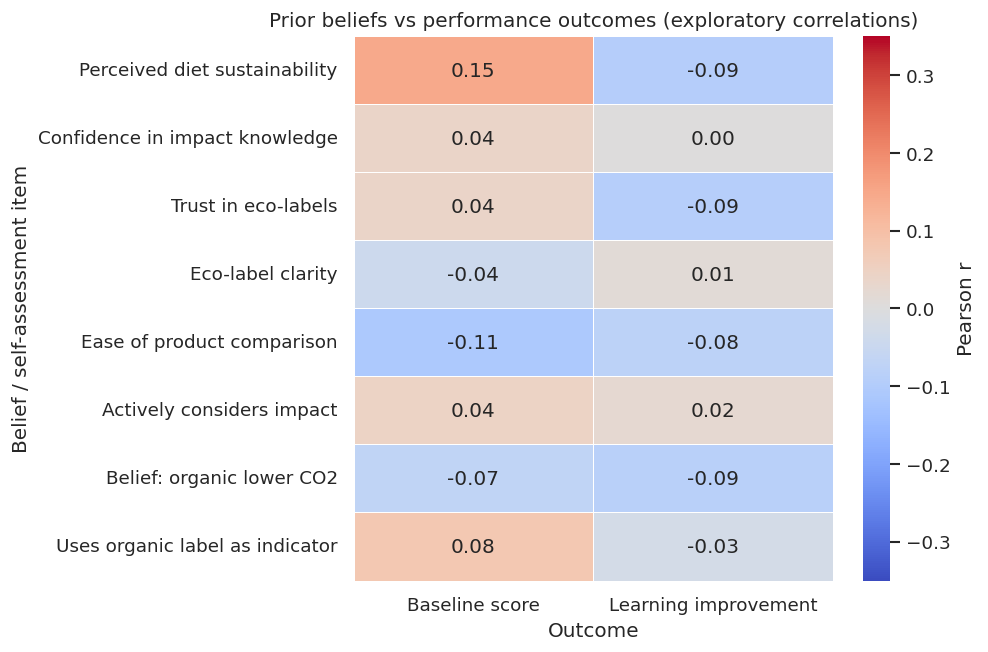

Saved /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/thesis/images/prior_belief_correlations.png
Saved /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/thesis/presentation_images/prior_belief_correlations.png


In [26]:
belief_label_map = {
    'pre_q1': 'Perceived diet sustainability',
    'pre_q2': 'Confidence in impact knowledge',
    'pre_q3': 'Trust in eco-labels',
    'pre_q4': 'Eco-label clarity',
    'pre_q5': 'Ease of product comparison',
    'pre_q6': 'Actively considers impact',
    'pre_q7': 'Belief: organic lower CO2',
    'pre_q8': 'Uses organic label as indicator',
}

available_belief_cols = [c for c in belief_label_map if c in analysis_df.columns]
outcomes = {
    'Baseline score': 'overall_baseline',
    'Learning improvement': 'overall_improvement',
}


def corr_stats(x, y):
    pair = pd.DataFrame({'x': x, 'y': y}).dropna()
    n = len(pair)
    if n < 4:
        return np.nan, np.nan, n, np.nan, np.nan
    r, p_value = stats.pearsonr(pair['x'], pair['y'])

    # Fisher z 95% CI for Pearson r (kept for table/reporting)
    if abs(r) >= 1:
        ci_low, ci_high = r, r
    else:
        z = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_low = z - 1.96 * se
        z_high = z + 1.96 * se
        ci_low = np.tanh(z_low)
        ci_high = np.tanh(z_high)

    return r, p_value, n, ci_low, ci_high


corr_rows = []
for belief_col in available_belief_cols:
    for outcome_label, outcome_col in outcomes.items():
        r, p_value, n, ci_low, ci_high = corr_stats(analysis_df[belief_col], analysis_df[outcome_col])
        corr_rows.append({
            'belief_col': belief_col,
            'belief': belief_label_map[belief_col],
            'outcome': outcome_label,
            'r': r,
            'p': p_value,
            'n': n,
            'ci_low': ci_low,
            'ci_high': ci_high,
        })

corr_df = pd.DataFrame(corr_rows)

if corr_df.empty:
    print('No prior-belief columns available for exploratory correlations.')
else:
    display_cols = ['belief', 'outcome', 'r', 'p', 'n', 'ci_low', 'ci_high']
    display(corr_df[display_cols].round({'r': 3, 'p': 3, 'ci_low': 3, 'ci_high': 3}))

    belief_order = [belief_label_map[c] for c in available_belief_cols]
    outcome_order = list(outcomes.keys())

    heatmap_df = (
        corr_df
        .pivot(index='belief', columns='outcome', values='r')
        .reindex(index=belief_order, columns=outcome_order)
    )

    fig, ax = plt.subplots(figsize=(8.2, 5.6))
    sns.heatmap(
        heatmap_df,
        ax=ax,
        cmap='coolwarm',
        center=0,
        vmin=-0.35,
        vmax=0.35,
        annot=True,
        fmt='.2f',
        linewidths=0.6,
        linecolor='white',
        cbar_kws={'label': 'Pearson r'}
    )

    ax.set_title('Prior beliefs vs performance outcomes (exploratory correlations)')
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Belief / self-assessment item')

    plt.tight_layout()

    beliefs_corr_path = THESIS_IMAGE_DIR / 'prior_belief_correlations.png'
    plt.savefig(beliefs_corr_path, dpi=300, bbox_inches='tight')

    beliefs_corr_presentation = THESIS_IMAGE_DIR.parent / 'presentation_images' / 'prior_belief_correlations.png'
    beliefs_corr_presentation.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(beliefs_corr_presentation, dpi=300, bbox_inches='tight')

    plt.show()
    print(f'Saved {beliefs_corr_path}')
    print(f'Saved {beliefs_corr_presentation}')

## 7. Catalog-level CO$_2$ distribution

This section reproduces the catalog-level statistics and Figure 4.1 from the thesis using `analysis_output/ah_catalog_co2_evaluated.json`. Pet-food and non-food products are excluded.

Catalog products in snapshot: 19,787
Matched human grocery products: 11,461
Median CO2: 1.80 kg CO2-eq/kg
Mean CO2: 4.73 kg CO2-eq/kg


,count
co2_bucket,
<1,1475
1-3,5678
3-5,1753
5-10,962
10-20,1289
>20,304


,count,median,mean
display_group,,,
Red meat,226,35.59,23.51
Cheese,138,12.00,10.22
Fish,131,8.21,9.95
Processed meats,326,7.64,11.18
Poultry,89,5.28,5.28
Coffee and tea,557,3.22,8.53
"Biscuits, sweets and chocolate",927,3.22,7.54
Snacks and crisps,895,3.43,6.57
Dairy and eggs,858,3.22,3.56


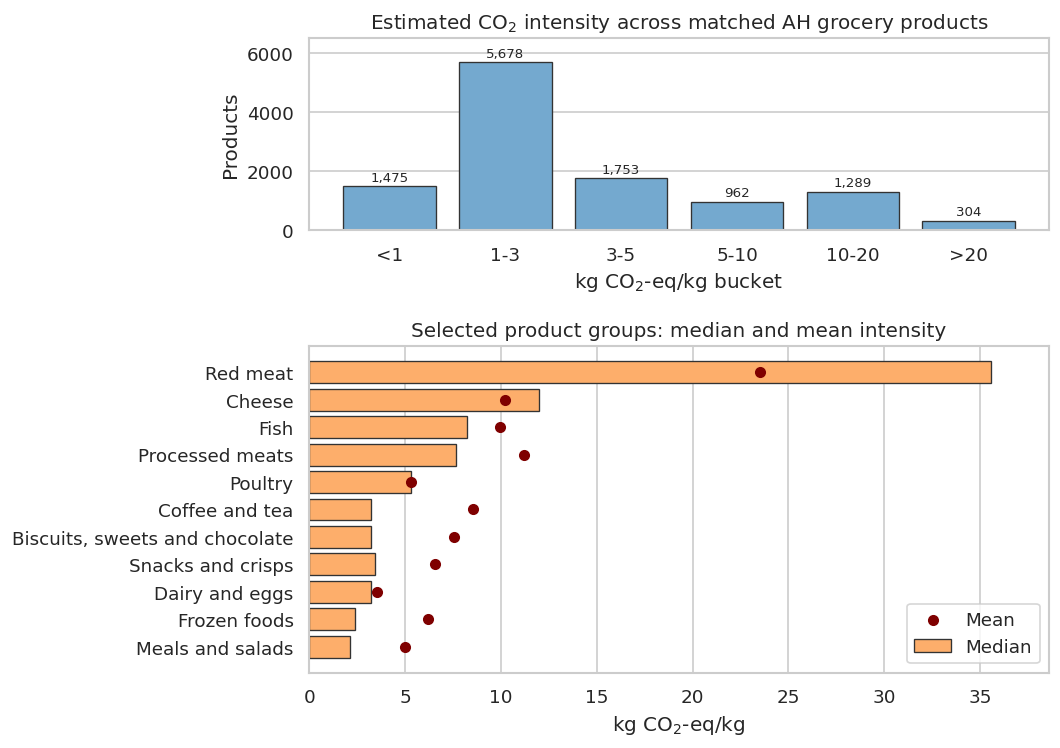

Saved /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/thesis/images/ah_catalog_co2_distribution.png


In [23]:
if not CATALOG_EXPORT.exists():
    raise FileNotFoundError(f'Missing catalog export: {CATALOG_EXPORT}')

with open(CATALOG_EXPORT, 'r', encoding='utf-8') as f:
    catalog_data = json.load(f)

catalog_df = pd.DataFrame(catalog_data.get('rows', []))
catalog_df['co2PerKg'] = pd.to_numeric(catalog_df['co2PerKg'], errors='coerce')
matched_catalog = catalog_df[
    catalog_df['matched'].eq(True)
    & catalog_df['co2PerKg'].notna()
    & ~catalog_df['sourceCategory'].eq('huisdier')
    & ~catalog_df['isNonFood'].eq(True)
].copy()

bucket_edges = [0, 1, 3, 5, 10, 20, np.inf]
bucket_labels = ['<1', '1-3', '3-5', '5-10', '10-20', '>20']
matched_catalog['co2_bucket'] = pd.cut(matched_catalog['co2PerKg'], bins=bucket_edges, labels=bucket_labels, right=False)
bucket_counts = matched_catalog['co2_bucket'].value_counts().reindex(bucket_labels).fillna(0).astype(int)

print(f"Catalog products in snapshot: {catalog_data.get('totalProducts', len(catalog_df)):,}")
print(f"Matched human grocery products: {len(matched_catalog):,}")
print(f"Median CO2: {matched_catalog['co2PerKg'].median():.2f} kg CO2-eq/kg")
print(f"Mean CO2: {matched_catalog['co2PerKg'].mean():.2f} kg CO2-eq/kg")
display(bucket_counts.to_frame('count'))

RED_MEAT_CATEGORIES = {'beef_herd', 'beef_dairy', 'bovine_meat', 'pig_meat', 'lamb_mutton', 'veal_meat', 'beef', 'pork', 'meat_red'}
POULTRY_CATEGORIES = {'poultry_meat', 'chicken', 'turkey'}
SOURCE_GROUPS = {
    'maaltijden': 'Meals and salads',
    'diepvries': 'Frozen foods',
    'zuivel': 'Dairy and eggs',
    'tussendoortjes': 'Snack foods',
    'koek_snoep': 'Biscuits, sweets and chocolate',
    'borrel_chips': 'Snacks and crisps',
    'vleeswaren': 'Processed meats',
    'vis': 'Fish',
    'kaas': 'Cheese',
    'koffie_thee': 'Coffee and tea',
}


def display_group(row):
    """Map AH shelf groups to thesis display groups.

    Red meat and poultry are split only within the AH meat shelf. This avoids
    reclassifying mixed or incorrectly matched products from other shelves,
    such as hamburger buns or sauces, as red meat.
    """
    source = row.get('sourceCategory')
    co2_cat = row.get('co2Category')
    if source == 'vlees' and co2_cat in POULTRY_CATEGORIES:
        return 'Poultry'
    if source == 'vlees' and co2_cat in RED_MEAT_CATEGORIES:
        return 'Red meat'
    return SOURCE_GROUPS.get(source)


matched_catalog['display_group'] = matched_catalog.apply(display_group, axis=1)
group_summary = (
    matched_catalog.dropna(subset=['display_group'])
    .groupby('display_group')['co2PerKg']
    .agg(count='count', median='median', mean='mean')
    .query('count >= 50')
)

# Keep the lower panel focused on groups discussed in the thesis.
plot_order = [
    'Red meat', 'Cheese', 'Fish', 'Processed meats', 'Poultry',
    'Coffee and tea', 'Biscuits, sweets and chocolate',
    'Snacks and crisps', 'Dairy and eggs', 'Frozen foods', 'Meals and salads'
]
plot_groups = group_summary.loc[[g for g in plot_order if g in group_summary.index]].copy()
display(plot_groups.round(2))

fig, axes = plt.subplots(2, 1, figsize=(9.0, 6.4), gridspec_kw={'height_ratios': [1, 1.7]})

# Upper panel: bucket counts.
axes[0].bar(bucket_counts.index.astype(str), bucket_counts.values, color='#74a9cf', edgecolor='#333333', linewidth=0.8)
axes[0].set_title('Estimated CO$_2$ intensity across matched AH grocery products', fontsize=12)
axes[0].set_xlabel('kg CO$_2$-eq/kg bucket')
axes[0].set_ylabel('Products')
axes[0].grid(axis='x', visible=False)
axes[0].set_ylim(0, 6500)
for i, value in enumerate(bucket_counts.values):
    axes[0].text(i, value + max(bucket_counts.values) * 0.015, f'{value:,}', ha='center', va='bottom', fontsize=8)

# Lower panel: median bars and mean markers for selected product groups.
y = np.arange(len(plot_groups))[::-1]
axes[1].barh(y, plot_groups['median'], color='#fdae6b', edgecolor='#333333', linewidth=0.8, label='Median')
axes[1].scatter(plot_groups['mean'], y, color='#7f0000', s=32, zorder=3, label='Mean')
axes[1].set_yticks(y)
axes[1].set_yticklabels(plot_groups.index)
axes[1].set_xlabel('kg CO$_2$-eq/kg')
axes[1].set_title('Selected product groups: median and mean intensity', fontsize=12)
axis_max = max(plot_groups['median'].max(), plot_groups['mean'].max()) + 3
axes[1].set_xlim(0, axis_max)
axes[1].grid(axis='y', visible=False)
axes[1].legend(loc='lower right', frameon=True)

plt.tight_layout(h_pad=1.4)
catalog_path = THESIS_IMAGE_DIR / 'ah_catalog_co2_distribution.png'
plt.savefig(catalog_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {catalog_path}')

## Notes on excluded exploratory work

Earlier versions of this notebook included exploratory cells for reversed-ranking detection, database correction dry-runs, broad demographic plots, qualitative response dumps, and lambda-sensitivity checks. Those cells were useful during development but are not directly used in the final thesis results. They have been removed from this notebook so that a supervisor can inspect a clean analysis workflow focused on the reported results.